In [1]:
import kagglehub

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


Folder: /kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat, Files count: 12499
Folder: /kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog, Files count: 12499


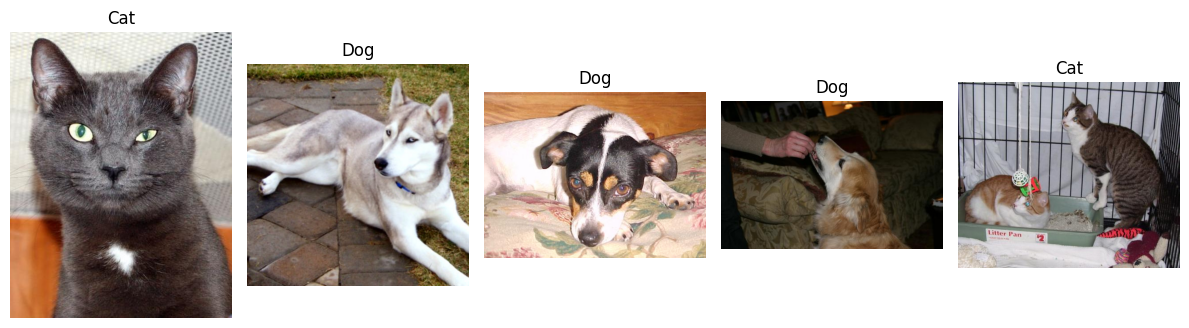

Number of classes: 2
Sample Image dimensions (Width, Height): [(357, 500), (500, 380), (231, 500)]
Total number of images: 24998


In [5]:
# Task 1
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

data_dir = "/kaggle/input/dog-and-cat-classification-dataset/PetImages"
categories = ["Cat", "Dog"]

for cat in categories:
    path = os.path.join(data_dir, cat)
    print(f"Folder: {path}, Files count: {len(os.listdir(path))}")

sample_images = []
for cat in categories:
    path = os.path.join(data_dir, cat)
    for img_name in os.listdir(path)[:3]:
        sample_images.append((os.path.join(path, img_name), cat))

random.shuffle(sample_images)

plt.figure(figsize=(12, 6))
for i, (img_path, label) in enumerate(sample_images[:5]):
    img = Image.open(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()

total_images = 0
image_dimensions = set()
for cat in categories:
    path = os.path.join(data_dir, cat)
    files = os.listdir(path)
    total_images += len(files)
    for f in files[:10]:
        with Image.open(os.path.join(path, f)) as img:
            image_dimensions.add(img.size)

print(f"Number of classes: {len(categories)}")
print(f"Sample Image dimensions (Width, Height): {list(image_dimensions)[:3]}")
print(f"Total number of images: {total_images}")

In [9]:
# Task 2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/dog-and-cat-classification-dataset/PetImages",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

test_generator = train_datagen.flow_from_directory(
    "/kaggle/input/dog-and-cat-classification-dataset/PetImages",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [ ]:
# Task 3
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
188/625 ━━━━━━━━━━━━━━━━━━━━ 7:58 1s/step - accuracy: 0.5569 - loss: 0.7006

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 773s 1s/step - accuracy: 0.6997 - loss: 0.5640 - val_accuracy: 0.7715 - val_loss: 0.4748
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 713s 1s/step - accuracy: 0.7909 - loss: 0.4457 - val_accuracy: 0.7899 - val_loss: 0.4506
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 726s 1s/step - accuracy: 0.8306 - loss: 0.3765 - val_accuracy: 0.8133 - val_loss: 0.4100
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 743s 1s/step - accuracy: 0.8630 - loss: 0.3133 - val_accuracy: 0.8299 - val_loss: 0.3739
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9065 - loss: 0.2300

In [ ]:
# Task 4
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

test_acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

Conclusion

The CNN model successfully classifies pet images into cats and dogs with high accuracy across 10 training epochs. Convolutional layers extract essential spatial features such as edges, textures, and shapes from input images, while pooling layers reduce spatial dimensions and computation, providing translation invariance. A major advantage of CNNs over standard Artificial Neural Networks (ANNs) for image tasks is parameter sharing and local connectivity, which preserves two-dimensional spatial structures without flattening images into huge 1D feature vectors that explode network parameters. However, a key limitation of CNNs is their requirement for large volumes of labeled training data and susceptibility to overfitting without proper regularization, data augmentation, or dropout.